# 07. Model Interpretation and Operational Risk Output

This notebook translates the validated Random Forest into transparent, business-ready risk outputs for analysis, Power BI and operational review.

It loads the selected models, threshold, feature metadata and scoring contract created in `06_ml_random_forest_portfolio.ipynb`. 

The notebook combines three complementary interpretation layers:

1. **Global model importance** — which features influence the forest overall?
2. **Local path contributions** — which model features increased or decreased a specific scoring row's high-risk probability?
3. **Business risk indicators** — which recognizable commercial conditions are present and what action might follow?


## Notebook roadmap

1. Configure input and output paths.
2. Load feature matrices, identifiers, human-readable features, validated models, and model metadata.
3. Verify that model features, threshold, rows, and upstream predictions align.
4. Generate historical and current scoring predictions with the frozen model logic.
5. Reproduce model metrics and threshold trade-offs without retraining.
6. Review global impurity and validation permutation importance.
7. Calculate local high-risk probability contributions for every current scoring row.
8. Add business-readable indicators and recommended actions.
9. Build dashboard, alert-queue, top-risk, monthly-monitoring, and lift tables.
10. Export all original files plus interpretation metadata and quality checks.


## 1. Setup and paths


In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support)

pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 190)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_SEED = 42
TARGET_COL = "next_month_risk_label"
RISK_LABELS = [0, 1, 2]
LABEL_NAMES = {0: "Low Risk", 1: "Medium Risk", 2: "High Risk"}
KEY_COLS = ["product_id", "region_id", "year_month"]

current_directory = Path.cwd().resolve()
PROJECT_ROOT = (
    current_directory.parent
    if current_directory.name.lower() in {"notebook", "notebooks"}
    else current_directory)

FEATURE_DIR = Path("../data/full_data/feature_engineering")
RANDOM_FOREST_DIR = Path("../data/full_data/ml_stronger")
OUTPUT_DIR = Path("../data/full_data/ml_interpretation_risk_output")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Feature folder:       {FEATURE_DIR}")
print(f"Random Forest folder: {RANDOM_FOREST_DIR}")
print(f"Output folder:        {OUTPUT_DIR}")


Feature folder:       ..\data\full_data\feature_engineering
Random Forest folder: ..\data\full_data\ml_stronger
Output folder:        ..\data\full_data\ml_interpretation_risk_output


## 2. Load upstream artifacts


In [2]:
def load_interpretation_inputs(feature_dir=FEATURE_DIR, random_forest_dir=RANDOM_FOREST_DIR):
    feature_paths = {
        "train_ml": feature_dir / "train_feature_engineered_ml_ready.csv",
        "valid_ml": feature_dir / "valid_feature_engineered_ml_ready.csv",
        "test_ml": feature_dir / "test_feature_engineered_ml_ready.csv",
        "scoring_ml": feature_dir / "scoring_feature_engineered_ml_ready.csv",
        "train_ids": feature_dir / "train_feature_engineered_ids.csv",
        "valid_ids": feature_dir / "valid_feature_engineered_ids.csv",
        "test_ids": feature_dir / "test_feature_engineered_ids.csv",
        "scoring_ids": feature_dir / "scoring_feature_engineered_ids.csv",
        "human_features": feature_dir / "feature_engineered_modeling_dataset.csv"}
    model_paths = {
        "train_model": random_forest_dir / "selected_random_forest_train_model.joblib",
        "refit_model": random_forest_dir / "selected_random_forest_refit_model.joblib",
        "configuration": random_forest_dir / "random_forest_model_config.json",
        "threshold_tradeoff": random_forest_dir / "high_risk_threshold_tuning_valid.csv",
        "global_importance": random_forest_dir / "random_forest_feature_importance.csv",
        "permutation_importance": random_forest_dir / "random_forest_permutation_importance_valid.csv",
        "stronger_model_results": random_forest_dir / "stronger_model_results.csv",
        "saved_test_predictions": random_forest_dir / "test_prediction_probabilities.csv",
        "saved_scoring_predictions": random_forest_dir / "random_forest_scoring_predictions.csv",
        "confidence_intervals": random_forest_dir / "random_forest_high_risk_confidence_intervals.csv"}

    all_paths = {**feature_paths, **model_paths}
    missing = [str(path) for path in all_paths.values() if not path.exists()]
    if missing:
        raise FileNotFoundError(
            "Missing required upstream artifacts:\n- " + "\n- ".join(missing))

    inputs = {
        name: pd.read_csv(path, low_memory=False)
        for name, path in feature_paths.items()}
    inputs.update(
        {
            "train_model": joblib.load(model_paths["train_model"]),
            "refit_model": joblib.load(model_paths["refit_model"]),
            "configuration": json.loads(model_paths["configuration"].read_text(encoding="utf-8")),
            "threshold_tradeoff": pd.read_csv(model_paths["threshold_tradeoff"]),
            "global_importance": pd.read_csv(model_paths["global_importance"]),
            "permutation_importance": pd.read_csv(model_paths["permutation_importance"]),
            "stronger_model_results": pd.read_csv(model_paths["stronger_model_results"]),
            "saved_test_predictions": pd.read_csv(model_paths["saved_test_predictions"]),
            "saved_scoring_predictions": pd.read_csv(model_paths["saved_scoring_predictions"]),
            "confidence_intervals": pd.read_csv(model_paths["confidence_intervals"])})
    return inputs, all_paths


In [3]:
inputs, upstream_paths = load_interpretation_inputs()

artifact_inventory = pd.DataFrame(
    [
        {
            "artifact": name,
            "filename": path.name,
            "size_bytes": path.stat().st_size}
        for name, path in upstream_paths.items()])
display(artifact_inventory)

,artifact,filename,size_bytes
0,train_ml,train_feature_engineered_ml_ready.csv,303911297
1,valid_ml,valid_feature_engineered_ml_ready.csv,59104242
2,test_ml,test_feature_engineered_ml_ready.csv,73898250
3,scoring_ml,scoring_feature_engineered_ml_ready.csv,7369201
4,train_ids,train_feature_engineered_ids.csv,3157075
5,valid_ids,valid_feature_engineered_ids.csv,616075
6,test_ids,test_feature_engineered_ids.csv,770075
7,scoring_ids,scoring_feature_engineered_ids.csv,73053
8,human_features,feature_engineered_modeling_dataset.csv,192697324
9,train_model,selected_random_forest_train_model.joblib,83250806


In [4]:
model_configuration = inputs["configuration"]
selected_threshold = float(model_configuration["selected_high_risk_threshold"])
train_model = inputs["train_model"]
refit_model = inputs["refit_model"]

print("Validated model configuration")
print("-" * 80)
print(f"Selected candidate: {model_configuration['selected_candidate']}")
print(f"High-risk threshold: {selected_threshold:.4f}")
print(f"Model library: {model_configuration['model_library']}")
print(f"Expected feature count: {model_configuration['feature_count']}")
display(pd.DataFrame([model_configuration["selected_parameters"]]).astype({"class_weight": str}))


Validated model configuration
--------------------------------------------------------------------------------
Selected candidate: balanced_medium
High-risk threshold: 0.4300
Model library: scikit-learn RandomForestClassifier
Expected feature count: 236


,candidate,n_estimators,max_depth,min_samples_leaf,max_features,class_weight
0,balanced_medium,220,14,3,sqrt,balanced_subsample


## 3. Standardize dates and validate the input contract


In [5]:
for name in ["train_ids", "valid_ids", "test_ids", "scoring_ids", "human_features"]:
    frame = inputs[name]
    frame["year_month"] = pd.to_datetime(frame["year_month"]).dt.to_period("M").dt.to_timestamp()
    if "target_month" in frame.columns:
        frame["target_month"] = pd.to_datetime(frame["target_month"]).dt.to_period("M").dt.to_timestamp()


def split_features_and_target(frame):
    if TARGET_COL not in frame.columns:
        raise KeyError(f"Missing target column: {TARGET_COL}")
    return frame.drop(columns=TARGET_COL).copy(), frame[TARGET_COL].astype(int).copy()


X_train, y_train = split_features_and_target(inputs["train_ml"])
X_valid, y_valid = split_features_and_target(inputs["valid_ml"])
X_test, y_test = split_features_and_target(inputs["test_ml"])
X_scoring = inputs["scoring_ml"].copy()

data_shapes = pd.DataFrame(
    {
        "split": ["train", "validation", "test", "scoring"],
        "rows": [len(X_train), len(X_valid), len(X_test), len(X_scoring)],
        "features": [X_train.shape[1], X_valid.shape[1], X_test.shape[1], X_scoring.shape[1]],
        "actual_target_known": [True, True, True, False]})
display(data_shapes)


,split,rows,features,actual_target_known
0,train,82000,236,True
1,validation,16000,236,True
2,test,20000,236,True
3,scoring,2000,236,False


In [6]:
expected_feature_names = list(train_model.feature_names_in_)
refit_feature_names = list(refit_model.feature_names_in_)

feature_contract = {
    "validation_matches_train": X_valid.columns.tolist() == X_train.columns.tolist(),
    "test_matches_train": X_test.columns.tolist() == X_train.columns.tolist(),
    "scoring_matches_train": X_scoring.columns.tolist() == X_train.columns.tolist(),
    "train_model_matches_input": expected_feature_names == X_train.columns.tolist(),
    "refit_model_matches_input": refit_feature_names == X_train.columns.tolist(),
    "configured_feature_count_matches": model_configuration["feature_count"] == X_train.shape[1]}
display(pd.DataFrame({"check": feature_contract.keys(), "passed": feature_contract.values()}))

feature_quality = pd.DataFrame(
    [
        {
            "split": split,
            "missing_values": int(X.isna().sum().sum()),
            "infinite_values": int(np.isinf(X.to_numpy(dtype=float)).sum()),
            "duplicate_columns": int(X.columns.duplicated().sum())}
        for split, X in [
            ("train", X_train),
            ("validation", X_valid),
            ("test", X_test),
            ("scoring", X_scoring)]])
display(feature_quality)

assert all(feature_contract.values())
assert feature_quality[["missing_values", "infinite_values", "duplicate_columns"]].eq(0).all().all()
assert TARGET_COL not in X_train.columns
assert not any(column.endswith("_id") for column in X_train.columns)


,check,passed
0,validation_matches_train,True
1,test_matches_train,True
2,scoring_matches_train,True
3,train_model_matches_input,True
4,refit_model_matches_input,True
5,configured_feature_count_matches,True


,split,missing_values,infinite_values,duplicate_columns
0,train,0,0,0
1,validation,0,0,0
2,test,0,0,0
3,scoring,0,0,0


In [7]:
identifier_alignment_rows = []
for split, ids, target, X in [
    ("train", inputs["train_ids"], y_train, X_train),
    ("valid", inputs["valid_ids"], y_valid, X_valid),
    ("test", inputs["test_ids"], y_test, X_test),
]:
    target_match = ids[TARGET_COL].astype(int).reset_index(drop=True).equals(target.reset_index(drop=True))
    identifier_alignment_rows.append(
        {
            "split": split,
            "rows_match": len(ids) == len(X),
            "target_values_match": target_match,
            "duplicate_keys": int(ids.duplicated(KEY_COLS).sum()),
            "first_target_month": ids["target_month"].min(),
            "last_target_month": ids["target_month"].max()})

scoring_ids = inputs["scoring_ids"]
identifier_alignment_rows.append(
    {
        "split": "scoring",
        "rows_match": len(scoring_ids) == len(X_scoring),
        "target_values_match": TARGET_COL not in scoring_ids.columns,
        "duplicate_keys": int(scoring_ids.duplicated(KEY_COLS).sum()),
        "first_target_month": scoring_ids["target_month"].min(),
        "last_target_month": scoring_ids["target_month"].max()})
identifier_alignment = pd.DataFrame(identifier_alignment_rows)
display(identifier_alignment)

assert identifier_alignment["rows_match"].all()
assert identifier_alignment["target_values_match"].all()
assert identifier_alignment["duplicate_keys"].eq(0).all()


,split,rows_match,target_values_match,duplicate_keys,first_target_month,last_target_month
0,train,True,True,0,2021-02-01,2024-06-01
1,valid,True,True,0,2024-07-01,2025-02-01
2,test,True,True,0,2025-03-01,2025-12-01
3,scoring,True,True,0,2026-01-01,2026-01-01


## 4. Generate predictions from the validated models


The train-period model produces historical train, validation, and test probabilities. The refitted model—trained only after final evaluation in the previous notebook—produces the current scoring probabilities.

The legacy `risk_score` remains `100 × high-risk probability` for downstream compatibility. A separate `risk_score_0_10` represents expected severity across all three classes: `0 × P(low) + 5 × P(medium) + 10 × P(high)`.


In [8]:
def aligned_probabilities(model, X):
    raw = model.predict_proba(X)
    aligned = np.zeros((len(X), len(RISK_LABELS)), dtype=float)
    class_positions = {int(label): position for position, label in enumerate(model.classes_)}
    for output_position, label in enumerate(RISK_LABELS):
        if label in class_positions:
            aligned[:, output_position] = raw[:, class_positions[label]]
    return aligned


def predict_with_threshold(probabilities, threshold):
    non_high_prediction = np.argmax(probabilities[:, :2], axis=1)
    return np.where(probabilities[:, 2] >= threshold, 2, non_high_prediction).astype(int)


def make_predictions_frame(
    split,
    ids,
    probabilities,
    threshold,
    actual_target=None,
    model_scope="train_period_model",
):
    prediction = predict_with_threshold(probabilities, threshold)
    output = ids.copy().reset_index(drop=True)
    output["split"] = split
    output["split_row_number"] = np.arange(len(output), dtype=int)
    output["model_scope"] = model_scope

    if actual_target is None:
        output[TARGET_COL] = pd.Series(pd.NA, index=output.index, dtype="Int64")
        output["actual_risk_label_num"] = pd.Series(pd.NA, index=output.index, dtype="Int64")
        output["actual_risk_label"] = pd.NA
    else:
        actual_values = np.asarray(actual_target, dtype=int)
        output["actual_risk_label_num"] = actual_values
        output["actual_risk_label"] = pd.Series(actual_values).map(LABEL_NAMES).to_numpy()

    output["predicted_risk_label_num"] = prediction
    output["predicted_risk_label"] = pd.Series(prediction).map(LABEL_NAMES).to_numpy()
    output["prob_low_risk"] = probabilities[:, 0]
    output["prob_medium_risk"] = probabilities[:, 1]
    output["high_risk_probability"] = probabilities[:, 2]
    output["high_risk_probability_pct"] = 100 * probabilities[:, 2]
    output["risk_score"] = (100 * probabilities[:, 2]).round(1)
    output["risk_score_0_10"] = probabilities @ np.array([0.0, 5.0, 10.0])
    output["selected_high_risk_threshold"] = threshold
    output["is_any_risk_alert"] = (prediction > 0).astype(int)
    output["is_high_risk_alert"] = (prediction == 2).astype(int)

    if actual_target is None:
        output["is_false_alarm"] = pd.Series(pd.NA, index=output.index, dtype="Int64")
        output["is_missed_high_risk"] = pd.Series(pd.NA, index=output.index, dtype="Int64")
    else:
        actual_high = np.asarray(actual_target, dtype=int) == 2
        predicted_high = prediction == 2
        output["is_false_alarm"] = (~actual_high & predicted_high).astype(int)
        output["is_missed_high_risk"] = (actual_high & ~predicted_high).astype(int)

    return output


In [9]:
train_probability = aligned_probabilities(train_model, X_train)
valid_probability = aligned_probabilities(train_model, X_valid)
test_probability = aligned_probabilities(train_model, X_test)
scoring_probability = aligned_probabilities(refit_model, X_scoring)

prediction_frames = [
    make_predictions_frame("train", inputs["train_ids"], train_probability, selected_threshold, y_train, "train_period_model_in_sample"),
    make_predictions_frame("valid", inputs["valid_ids"], valid_probability, selected_threshold, y_valid, "train_period_model_out_of_time"),
    make_predictions_frame("test", inputs["test_ids"], test_probability, selected_threshold, y_test, "train_period_model_out_of_time"),
    make_predictions_frame("scoring", inputs["scoring_ids"], scoring_probability, selected_threshold, None, "refit_model_current_scoring")]
predictions = pd.concat(prediction_frames, ignore_index=True)

prediction_summary = predictions.groupby(
    ["split", "predicted_risk_label"],
    as_index=False,
).agg(
    rows=("product_id", "size"),
    average_high_risk_probability=("high_risk_probability", "mean"),
    average_risk_score_0_10=("risk_score_0_10", "mean"))
display(prediction_summary)


,split,predicted_risk_label,rows,average_high_risk_probability,average_risk_score_0_10
0,scoring,High Risk,123,0.7329,8.1124
1,scoring,Low Risk,929,0.0147,1.2400
2,scoring,Medium Risk,948,0.0287,3.5657
3,test,High Risk,1646,0.7211,8.0635
4,test,Low Risk,10147,0.0137,1.0420
5,test,Medium Risk,8207,0.0342,3.5541
6,train,High Risk,7563,0.7659,8.3513
7,train,Low Risk,43658,0.0096,0.8312
8,train,Medium Risk,30779,0.0311,3.6908
9,valid,High Risk,1365,0.7168,8.0211


### Check against the predictions exported by the Random Forest notebook


In [10]:
saved_test = inputs["saved_test_predictions"]
saved_scoring = inputs["saved_scoring_predictions"]

upstream_prediction_checks = {
    "test_row_count_matches": len(saved_test) == len(test_probability),
    "test_high_probability_matches": np.allclose(saved_test["proba_high"], test_probability[:, 2]),
    "test_tuned_label_matches": np.array_equal(saved_test["predicted_label_tuned"].astype(int), predict_with_threshold(test_probability, selected_threshold)),
    "scoring_row_count_matches": len(saved_scoring) == len(scoring_probability),
    "scoring_high_probability_matches": np.allclose(saved_scoring["probability_high_risk"], scoring_probability[:, 2]),
    "scoring_label_matches": np.array_equal(saved_scoring["predicted_risk_label"].astype(int), predict_with_threshold(scoring_probability, selected_threshold))}
display(pd.DataFrame({"check": upstream_prediction_checks.keys(), "passed": upstream_prediction_checks.values()}))
assert all(upstream_prediction_checks.values())


,check,passed
0,test_row_count_matches,True
1,test_high_probability_matches,True
2,test_tuned_label_matches,True
3,scoring_row_count_matches,True
4,scoring_high_probability_matches,True
5,scoring_label_matches,True


## 5. Reproduce historical performance without retraining


In [11]:
def evaluate_labeled_predictions(split, y_true, probabilities, threshold):
    prediction = predict_with_threshold(probabilities, threshold)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        prediction,
        labels=RISK_LABELS,
        zero_division=0)
    class_report = pd.DataFrame(
        {
            "label": RISK_LABELS,
            "label_name": [LABEL_NAMES[label] for label in RISK_LABELS],
            "precision": precision,
            "recall": recall,
            "f1_score": f1,
            "support": support.astype(int)})
    matrix_values = confusion_matrix(y_true, prediction, labels=RISK_LABELS)
    matrix = pd.DataFrame(
        matrix_values,
        index=[f"actual_{LABEL_NAMES[label]}" for label in RISK_LABELS],
        columns=[f"pred_{LABEL_NAMES[label]}" for label in RISK_LABELS])

    actual_high = np.asarray(y_true) == 2
    predicted_high = prediction == 2
    tp = int((actual_high & predicted_high).sum())
    fp = int((~actual_high & predicted_high).sum())
    fn = int((actual_high & ~predicted_high).sum())
    tn = int((~actual_high & ~predicted_high).sum())
    high_precision = tp / (tp + fp) if (tp + fp) else 0.0
    high_recall = tp / (tp + fn) if (tp + fn) else 0.0
    high_f2 = (
        5 * high_precision * high_recall / (4 * high_precision + high_recall)
        if (4 * high_precision + high_recall) > 0
        else 0.0)
    metrics = {
        "split": split,
        "evaluation_role": "in_sample" if split == "train" else "out_of_time",
        "accuracy": float(accuracy_score(y_true, prediction)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, prediction)),
        "macro_f1": float(f1_score(y_true, prediction, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, prediction, average="weighted", zero_division=0)),
        "high_risk_recall": high_recall,
        "high_risk_precision": high_precision,
        "high_risk_f2": high_f2,
        "false_alarm_rate": fp / (fp + tn) if (fp + tn) else 0.0,
        "alert_rate": float(predicted_high.mean()),
        "any_risk_alert_rate": float((prediction > 0).mean()),
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn}
    return metrics, class_report, matrix


In [12]:
historical_evaluations = {
    "train": evaluate_labeled_predictions("train", y_train, train_probability, selected_threshold),
    "valid": evaluate_labeled_predictions("valid", y_valid, valid_probability, selected_threshold),
    "test": evaluate_labeled_predictions("test", y_test, test_probability, selected_threshold)}
risk_output_model_metrics = pd.DataFrame(
    [output[0] for output in historical_evaluations.values()])
display(risk_output_model_metrics.round(4))


,split,evaluation_role,accuracy,balanced_accuracy,macro_f1,weighted_f1,high_risk_recall,high_risk_precision,high_risk_f2,false_alarm_rate,alert_rate,any_risk_alert_rate,tp,fp,fn,tn
0,train,in_sample,0.8194,0.8889,0.7705,0.8283,0.9969,0.5178,0.8412,0.0467,0.0922,0.4676,3916,3647,12,74425
1,valid,out_of_time,0.7089,0.7889,0.6648,0.7213,0.9358,0.4381,0.7626,0.0499,0.0853,0.4970,598,767,41,14594
2,test,out_of_time,0.7090,0.7809,0.6579,0.7228,0.9066,0.4247,0.7389,0.0492,0.0823,0.4926,699,947,72,18282


In [13]:
print("Test confusion matrix")
display(historical_evaluations["test"][2])

print("Test classification report")
display(historical_evaluations["test"][1].round(4))

print("Previously calculated 95% intervals")
display(inputs["confidence_intervals"].round(4))


Test confusion matrix


,pred_Low Risk,pred_Medium Risk,pred_High Risk
actual_Low Risk,9163,3857,525
actual_Medium Risk,944,4318,422
actual_High Risk,40,32,699


Test classification report


,label,label_name,precision,recall,f1_score,support
0,0,Low Risk,0.9030,0.6765,0.7735,13545
1,1,Medium Risk,0.5261,0.7597,0.6217,5684
2,2,High Risk,0.4247,0.9066,0.5784,771


Previously calculated 95% intervals


,split,metric,estimate,successes,trials,lower_95_pct,upper_95_pct
0,validation,high_risk_precision,0.4381,598,1365,0.4120,0.4646
1,validation,high_risk_recall,0.9358,598,639,0.9141,0.9524
2,test,high_risk_precision,0.4247,699,1646,0.4010,0.4487
3,test,high_risk_recall,0.9066,699,771,0.8840,0.9252


## 6. Threshold trade-off used by the operational output


In [14]:
false_alarm_recall_tradeoff = inputs["threshold_tradeoff"].copy()

# Preserve that meaning while retaining the broader any-risk rate separately.
if "alert_rate" in false_alarm_recall_tradeoff.columns:
    false_alarm_recall_tradeoff["any_risk_alert_rate"] = false_alarm_recall_tradeoff["alert_rate"]
false_alarm_recall_tradeoff["alert_rate"] = false_alarm_recall_tradeoff["high_risk_alert_rate"]

selected_tradeoff_row = false_alarm_recall_tradeoff.loc[
    np.isclose(false_alarm_recall_tradeoff["threshold"], selected_threshold)]
display(
    selected_tradeoff_row[
        [
            "threshold",
            "macro_f1",
            "high_risk_precision",
            "high_risk_recall",
            "high_risk_f2",
            "false_alarm_rate",
            "alert_rate"]].round(4))


,threshold,macro_f1,high_risk_precision,high_risk_recall,high_risk_f2,false_alarm_rate,alert_rate
100,0.4300,0.6648,0.4381,0.9358,0.7626,0.0499,0.0853


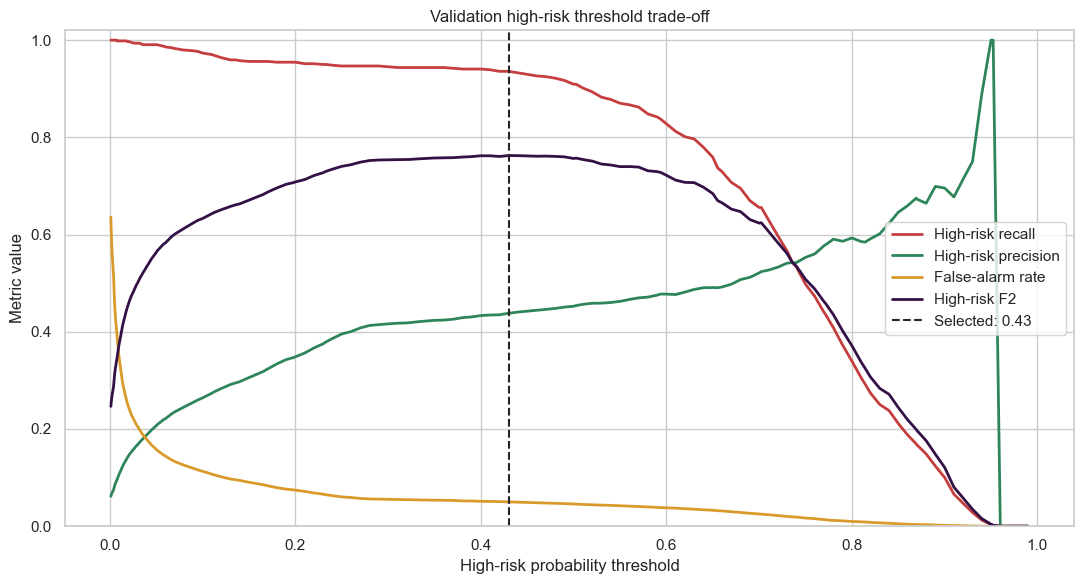

Chart path: ..\data\full_data\ml_interpretation_risk_output\false_alarm_recall_tradeoff.png


In [15]:
def create_tradeoff_chart(tradeoff, selected_threshold, output_dir=OUTPUT_DIR):
    ordered = tradeoff.sort_values("threshold")
    fig, ax = plt.subplots(figsize=(11, 6))
    ax.plot(ordered["threshold"], ordered["high_risk_recall"], label="High-risk recall", color="#C53D3D", linewidth=2)
    ax.plot(ordered["threshold"], ordered["high_risk_precision"], label="High-risk precision", color="#2F855A", linewidth=2)
    ax.plot(ordered["threshold"], ordered["false_alarm_rate"], label="False-alarm rate", color="#D99A2B", linewidth=2)
    ax.plot(ordered["threshold"], ordered["high_risk_f2"], label="High-risk F2", color="#331045", linewidth=2)
    ax.axvline(selected_threshold, color="#26232A", linestyle="--", label=f"Selected: {selected_threshold:.2f}")
    ax.set_title("Validation high-risk threshold trade-off")
    ax.set_xlabel("High-risk probability threshold")
    ax.set_ylabel("Metric value")
    ax.set_ylim(0, 1.02)
    ax.legend()
    fig.tight_layout()
    chart_path = output_dir / "false_alarm_recall_tradeoff.png"
    fig.savefig(chart_path, dpi=180, bbox_inches="tight")
    plt.show()
    return chart_path


tradeoff_chart_path = create_tradeoff_chart(
    false_alarm_recall_tradeoff,
    selected_threshold)
print(f"Chart path: {tradeoff_chart_path}")


## 7. Global model interpretation


Two global views are retained from the model-development notebook:

- **Impurity importance:** how often and how effectively a feature reduced node impurity across the forest.
- **Validation permutation importance:** how much validation macro F1 changed when a top feature was shuffled.

Agreement between the two views is more reassuring than relying on impurity importance alone.


In [16]:
risk_output_feature_importance = inputs["global_importance"].copy()
required_importance_columns = ["feature", "importance"]
assert set(required_importance_columns).issubset(risk_output_feature_importance.columns)

display(risk_output_feature_importance.head(20).round(5))
display(inputs["permutation_importance"].head(15).round(5))


,rank,feature,importance,cumulative_importance
0,1,customers_lag_1m,0.0402,0.0402
1,2,units_lag_1m,0.0394,0.0796
2,3,revenue_lag_1m,0.0392,0.1189
3,4,trend_slope_3m,0.0376,0.1565
4,5,volatility_3m,0.0372,0.1936
5,6,revenue_volatility_3m,0.0340,0.2276
6,7,unit_share_lag_1m,0.0338,0.2613
7,8,customer_share_category_region,0.0303,0.2917
8,9,units_lag_3m,0.0279,0.3195
9,10,product_unit_share_category_region,0.0261,0.3456


,feature,baseline_validation_macro_f1,mean_macro_f1_drop,std_macro_f1_drop,repeats
0,units_lag_3m,0.6648,0.0195,0.0009,3
1,trend_slope_3m,0.6648,0.0137,0.0015,3
2,risk_factor_volatility,0.6648,0.0095,0.0008,3
3,volatility_3m,0.6648,0.0057,0.0014,3
4,revenue_volatility_3m,0.6648,0.0041,0.0005,3
5,customer_share_category_region,0.6648,-0.0010,0.0007,3
6,rolling_units_mean_3m,0.6648,-0.0021,0.0002,3
7,units_lag_1m,0.6648,-0.0024,0.0002,3
8,cogs_eur,0.6648,-0.0024,0.0009,3
9,customers_lag_1m,0.6648,-0.0027,0.0007,3


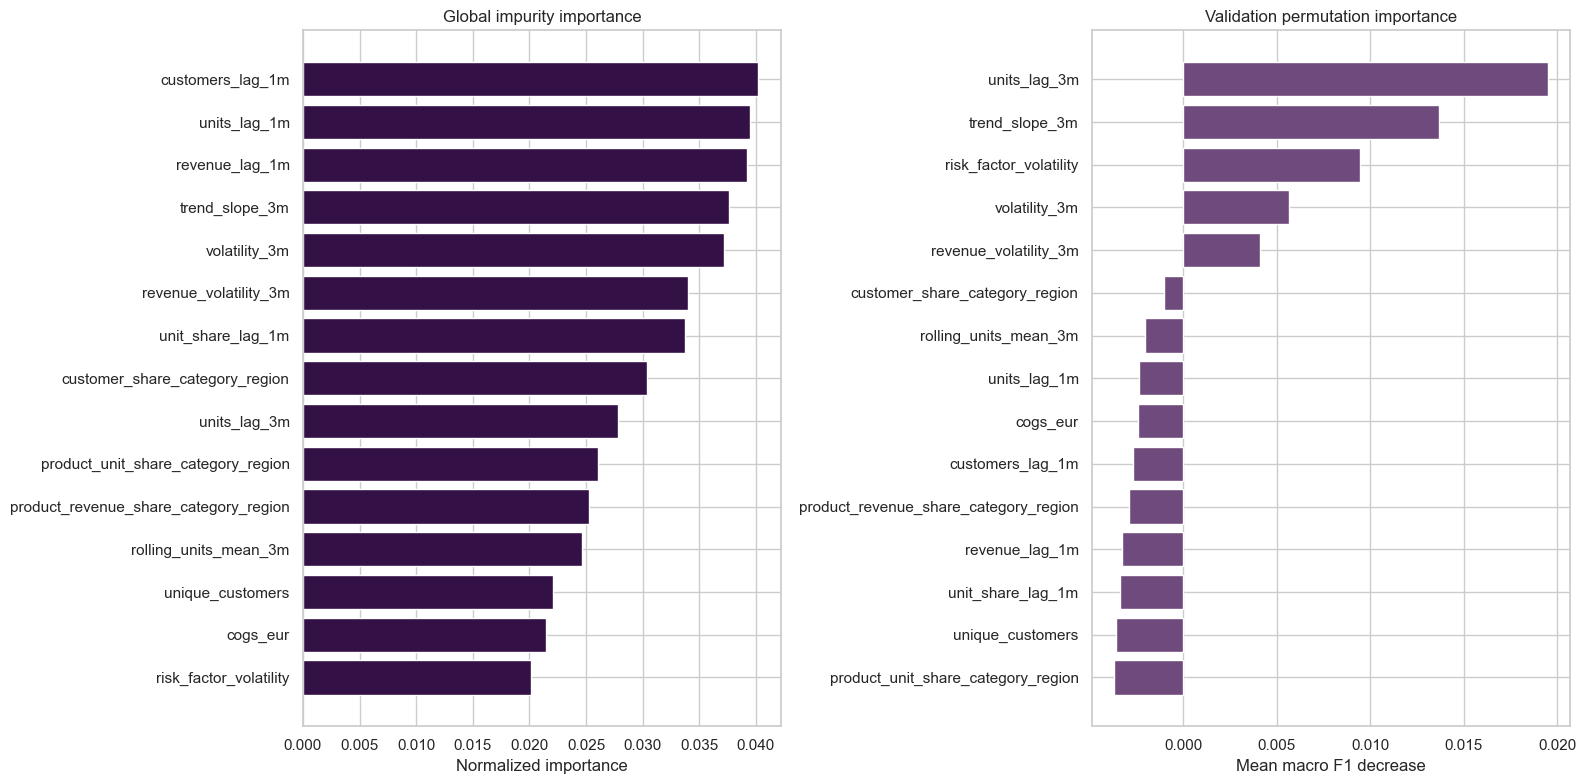

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

impurity_plot = risk_output_feature_importance.head(15).sort_values("importance")
axes[0].barh(impurity_plot["feature"], impurity_plot["importance"], color="#331045")
axes[0].set_title("Global impurity importance")
axes[0].set_xlabel("Normalized importance")
axes[0].set_ylabel("")

permutation_plot = inputs["permutation_importance"].head(15).sort_values("mean_macro_f1_drop")
axes[1].barh(permutation_plot["feature"], permutation_plot["mean_macro_f1_drop"], color="#6F4A7C")
axes[1].set_title("Validation permutation importance")
axes[1].set_xlabel("Mean macro F1 decrease")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


In [18]:
def feature_family(feature):
    name = feature.lower()
    rules = [
        ("Risk and trend", ["risk_factor", "trend", "momentum", "lag", "rolling", "volatility", "acceleration"]),
        ("Customer", ["customer", "churn", "order_share", "order_size"]),
        ("Profitability", ["margin", "profit", "revenue", "cogs", "cost", "discount", "asp"]),
        ("Supply and returns", ["stock", "inventory", "backorder", "supply", "lead_time", "return", "production"]),
        ("Market and competition", ["market", "competitor", "share_category", "category_region"]),
        ("Marketing and digital", ["campaign", "website", "demo", "page_view", "click", "impression", "digital"]),
        ("Product and lifecycle", ["product", "lifecycle", "launch", "age_month"]),
        ("Sales organization", ["sales_rep", "quota", "pipeline", "crm", "activity"]),
        ("Region and macro", ["region", "gdp", "inflation", "fx", "business_index"])]
    for family, tokens in rules:
        if any(token in name for token in tokens):
            return family
    return "Other"

risk_output_feature_importance["feature_family"] = risk_output_feature_importance["feature"].map(feature_family)
risk_output_feature_family_importance = (
    risk_output_feature_importance.groupby("feature_family", as_index=False)
    .agg(
        total_importance=("importance", "sum"),
        feature_count=("feature", "size"),
        top_feature=("feature", "first"))
    .sort_values("total_importance", ascending=False)
    .reset_index(drop=True))
display(risk_output_feature_family_importance.round(4))


,feature_family,total_importance,feature_count,top_feature
0,Risk and trend,0.4893,36,customers_lag_1m
1,Profitability,0.1549,34,product_revenue_share_category_region
2,Other,0.1045,30,mom_units_growth_pct
3,Customer,0.0810,17,customer_share_category_region
4,Market and competition,0.0548,17,product_unit_share_category_region
5,Sales organization,0.0429,12,active_sales_reps
6,Supply and returns,0.0338,23,inventory_months_cover
7,Marketing and digital,0.0203,25,digital_interest_per_unit
8,Product and lifecycle,0.0110,30,product_age_months
9,Region and macro,0.0074,12,macro_business_index


## 8. Local model contributions for current scoring rows


For each tree, class probabilities change as a row moves from the root to a leaf. We assign each change to the feature used at that split and average across all trees.

For every row and every class:

`average root probability + sum(feature path contributions) = predicted class probability`

Dashboard drivers explain the row's **predicted class**. Therefore, a medium-risk row is explained through its medium-risk probability and a high-risk row through its high-risk probability. Positive contributions increase that class probability; negative contributions decrease it. This is an exact decomposition of the model's path for the row, but it is not a Shapley-value explanation.


In [19]:
# scikit-learn converts tree inputs to float32 internally. Matching that precision ensures rows near a split threshold follow the exact same branch during explanation and prediction.
def random_forest_path_contributions(model, X):
    values = X.to_numpy(dtype=np.float32)
    contributions = np.zeros((len(X), X.shape[1], len(RISK_LABELS)), dtype=float)
    base_probability = np.zeros((len(X), len(RISK_LABELS)), dtype=float)
    tree_count = len(model.estimators_)

    for estimator in model.estimators_:
        tree = estimator.tree_
        node_values = tree.value[:, 0, :].astype(float)
        denominators = node_values.sum(axis=1, keepdims=True)
        node_probabilities = np.divide(
            node_values,
            denominators,
            out=np.zeros_like(node_values, dtype=float),
            where=denominators != 0)

        for row_number, row in enumerate(values):
            node = 0
            base_probability[row_number] += node_probabilities[node] / tree_count

            while tree.children_left[node] != tree.children_right[node]:
                feature_position = tree.feature[node]
                if row[feature_position] <= tree.threshold[node]:
                    child = tree.children_left[node]
                else:
                    child = tree.children_right[node]

                contributions[row_number, feature_position, :] += (
                    node_probabilities[child]
                    - node_probabilities[node]
                ) / tree_count
                node = child

    return base_probability, contributions


In [20]:
scoring_base_probability, scoring_contributions = random_forest_path_contributions(
    refit_model,
    X_scoring)
reconstructed_scoring_probability = scoring_base_probability + scoring_contributions.sum(axis=1)
explanation_reconstruction_error = np.abs(
    reconstructed_scoring_probability - scoring_probability)

explanation_check = pd.DataFrame(
    {
        "maximum_absolute_reconstruction_error": [explanation_reconstruction_error.max()],
        "mean_absolute_reconstruction_error": [explanation_reconstruction_error.mean()],
        "rows_explained": [len(X_scoring)],
        "features_considered": [X_scoring.shape[1]],
        "trees_per_explanation": [len(refit_model.estimators_)]})
display(explanation_check)
assert explanation_reconstruction_error.max() < 1e-10


,maximum_absolute_reconstruction_error,mean_absolute_reconstruction_error,rows_explained,features_considered,trees_per_explanation
0,0.0000,0.0000,2000,236,220


In [21]:
def readable_feature_name(feature):
    return (
        feature.replace("__", ": ")
        .replace("_", " ")
        .strip()
        .title())


def build_local_contribution_outputs(
    ids,
    feature_names,
    contributions,
    base_probability,
    predicted_labels,
    class_probability,
    top_n=5
):
    long_rows = []
    wide_rows = []

    for row_number in range(len(ids)):
        explained_class = int(predicted_labels[row_number])
        row_contributions = contributions[row_number, :, explained_class]
        ranked_positions = np.argsort(np.abs(row_contributions))[::-1][:top_n]

        wide_row = {
            "split": "scoring",
            "split_row_number": row_number,
            "model_explained_class": LABEL_NAMES[explained_class],
            "model_explained_class_probability": class_probability[row_number, explained_class],
            "model_explained_class_base_probability": base_probability[row_number, explained_class],
            "model_high_risk_base_probability": base_probability[row_number, 2]}

        for rank, feature_position in enumerate(ranked_positions, start=1):
            feature = feature_names[feature_position]
            contribution = float(row_contributions[feature_position])
            direction = (
                "increases predicted class probability"
                if contribution > 0
                else "decreases predicted class probability"
                if contribution < 0
                else "neutral")
            feature_label = readable_feature_name(feature)

            long_rows.append(
                {
                    "split": "scoring",
                    "split_row_number": row_number,
                    "product_id": ids.iloc[row_number]["product_id"],
                    "region_id": ids.iloc[row_number]["region_id"],
                    "year_month": ids.iloc[row_number]["year_month"],
                    "driver_rank": rank,
                    "feature": feature,
                    "feature_label": feature_label,
                    "explained_class_num": explained_class,
                    "explained_class": LABEL_NAMES[explained_class],
                    "explained_class_probability": class_probability[row_number, explained_class],
                    "contribution_to_explained_class_probability": contribution,
                    "contribution_to_high_risk_probability": float(contributions[row_number, feature_position, 2]),
                    "contribution_percentage_points": 100 * contribution,
                    "direction": direction})
            wide_row[f"model_driver_{rank}"] = feature_label
            wide_row[f"model_driver_{rank}_contribution_pp"] = 100 * contribution
            wide_row[f"model_driver_{rank}_direction"] = direction

        wide_rows.append(wide_row)

    return pd.DataFrame(long_rows), pd.DataFrame(wide_rows)


scoring_local_path_contributions, scoring_local_driver_wide = build_local_contribution_outputs(
    inputs["scoring_ids"],
    X_scoring.columns.to_numpy(),
    scoring_contributions,
    scoring_base_probability,
    predict_with_threshold(scoring_probability, selected_threshold),
    scoring_probability,
    top_n=5)
display(scoring_local_path_contributions.head(15).round(5))


,split,split_row_number,product_id,region_id,year_month,driver_rank,feature,feature_label,explained_class_num,explained_class,explained_class_probability,contribution_to_explained_class_probability,contribution_to_high_risk_probability,contribution_percentage_points,direction
0,scoring,0,1000,1,2025-12-01,1,customer_share_category_region,Customer Share Category Region,0,Low Risk,0.5085,0.0546,-0.0061,5.4590,increases predicted class probability
1,scoring,0,1000,1,2025-12-01,2,unique_customers,Unique Customers,0,Low Risk,0.5085,-0.0265,0.0087,-2.6458,decreases predicted class probability
2,scoring,0,1000,1,2025-12-01,3,units_lag_1m,Units Lag 1M,0,Low Risk,0.5085,0.0187,-0.0570,1.8750,increases predicted class probability
3,scoring,0,1000,1,2025-12-01,4,active_sales_reps,Active Sales Reps,0,Low Risk,0.5085,-0.0174,0.0036,-1.7391,decreases predicted class probability
4,scoring,0,1000,1,2025-12-01,5,regional_crm_activity_index,Regional Crm Activity Index,0,Low Risk,0.5085,0.0169,-0.0010,1.6949,increases predicted class probability
5,scoring,1,1000,10,2025-12-01,1,risk_factor_volatility,Risk Factor Volatility,1,Medium Risk,0.7881,0.1018,0.0006,10.1767,increases predicted class probability
6,scoring,1,1000,10,2025-12-01,2,volatility_3m,Volatility 3M,1,Medium Risk,0.7881,0.0428,0.0017,4.2832,increases predicted class probability
7,scoring,1,1000,10,2025-12-01,3,units_lag_1m,Units Lag 1M,1,Medium Risk,0.7881,0.0417,-0.0228,4.1663,increases predicted class probability
8,scoring,1,1000,10,2025-12-01,4,revenue_volatility_3m,Revenue Volatility 3M,1,Medium Risk,0.7881,0.0403,0.0027,4.0352,increases predicted class probability
9,scoring,1,1000,10,2025-12-01,5,rolling_units_cv_6m,Rolling Units Cv 6M,1,Medium Risk,0.7881,0.0396,-0.0003,3.9574,increases predicted class probability


## 9. Add human-readable business context


The model contribution fields answer, “What moved this model probability?” The following rules answer a different question: “Which recognizable business conditions are currently present?” Both are useful, so the dashboard keeps them in separate columns.


In [22]:
def build_business_indicator_list(row):
    indicators = []
    if row.get("risk_factor_under_trend", 0) == 1:
        indicators.append("Sales below trend")
    if row.get("risk_factor_volatility", 0) == 1:
        indicators.append("High sales volatility")
    if row.get("risk_factor_sales_drop", 0) == 1:
        indicators.append("Consecutive sales drop")
    if row.get("risk_factor_customer_drop", 0) == 1:
        indicators.append("Customer decline")
    if row.get("stockout_flag", 0) == 1 or row.get("supply_pressure_score", 0) > 0.35:
        indicators.append("Supply pressure")
    if row.get("lead_time_risk_flag", 0) == 1:
        indicators.append("Long lead time")
    if row.get("unit_share_change_pct", 0) < -0.20:
        indicators.append("Losing category share")
    if row.get("customer_count_growth_pct", 0) < -0.20:
        indicators.append("Declining customer base")
    if row.get("market_tailwind_score", 0) < -8:
        indicators.append("Weak market context")
    if row.get("high_competition_flag", 0) == 1:
        indicators.append("High competitor pressure")
    if row.get("margin_gap_vs_target", 0) < -0.10:
        indicators.append("Margin below target")
    if row.get("campaign_active_with_no_sales", 0) == 1:
        indicators.append("Campaign not converting")
    return indicators


def build_business_indicator_string(row):
    indicators = build_business_indicator_list(row)
    return "; ".join(indicators[:5]) if indicators else "No major rule-based indicator"


def recommended_action(row):
    indicators = build_business_indicator_list(row)
    if row["predicted_risk_label_num"] == 2:
        if "Supply pressure" in indicators or "Long lead time" in indicators:
            return "Review stock, replenishment, and supplier lead times immediately"
        if "Customer decline" in indicators or "Consecutive sales drop" in indicators:
            return "Launch account-level sales review and contact affected customers"
        if "Margin below target" in indicators:
            return "Review discounting, pricing, and product profitability"
        return "Escalate for commercial review and document owner action"
    if row["predicted_risk_label_num"] == 1:
        return "Monitor next month and assign an owner if deterioration continues"
    return "No immediate action; continue routine monitoring"


In [23]:
human_features = inputs["human_features"]
context_columns = [
    "product_id", "region_id", "year_month", "product_line", "product_category", "product_name",
    "lifecycle_stage", "units_sold", "revenue", "unique_customers", "avg_discount_pct",
    "market_demand_index", "competitor_pressure_index", "stockout_flag", "backorder_units",
    "campaign_flag", "campaign_spend", "website_visits", "demo_requests",
    "estimated_gross_profit", "estimated_gross_margin_pct", "product_unit_share_category_region",
    "unit_share_change_pct", "risk_factor_under_trend", "risk_factor_volatility",
    "risk_factor_sales_drop", "risk_factor_customer_drop", "supply_pressure_score",
    "lead_time_risk_flag", "customer_count_growth_pct", "market_tailwind_score",
    "high_competition_flag", "margin_gap_vs_target", "campaign_active_with_no_sales",
    "commercial_pressure_score", "demand_supply_mismatch_flag", "revenue_at_risk_proxy"]
available_context_columns = [column for column in context_columns if column in human_features.columns]

dashboard = predictions.merge(
    human_features[available_context_columns],
    on=KEY_COLS,
    how="left",
    validate="1:1",
    indicator="context_merge_status")
context_coverage = float((dashboard["context_merge_status"] == "both").mean())
dashboard = dashboard.drop(columns="context_merge_status")

dashboard = dashboard.merge(
    scoring_local_driver_wide,
    on=["split", "split_row_number"],
    how="left",
    validate="1:1")

dashboard["business_risk_indicators"] = dashboard.apply(build_business_indicator_string, axis=1)
dashboard["risk_drivers"] = dashboard["business_risk_indicators"]  # backward-compatible name
dashboard["recommended_action"] = dashboard.apply(recommended_action, axis=1)
dashboard["business_indicator_count"] = dashboard.apply(
    lambda row: len(build_business_indicator_list(row)), axis=1)

print(f"Human-readable context coverage: {context_coverage:.2%}")
display(
    dashboard.loc[
        dashboard["split"] == "scoring",
        [
            "product_id", "region", "year_month", "predicted_risk_label",
            "risk_score", "risk_score_0_10", "model_driver_1",
            "business_risk_indicators", "recommended_action"]].head(10))


Human-readable context coverage: 100.00%


,product_id,region,year_month,predicted_risk_label,risk_score,risk_score_0_10,model_driver_1,business_risk_indicators,recommended_action
118000,1000,DACH,2025-12-01,Low Risk,0.1000,2.4613,Customer Share Category Region,Sales below trend; Customer decline; Supply pr...,No immediate action; continue routine monitoring
118001,1000,APAC,2025-12-01,Medium Risk,0.0000,3.9407,Risk Factor Volatility,Sales below trend; High sales volatility; Cust...,Monitor next month and assign an owner if dete...
118002,1000,Western Europe,2025-12-01,Medium Risk,6.6000,3.1095,Trend Slope 3M,High sales volatility; Supply pressure,Monitor next month and assign an owner if dete...
118003,1000,Southern Europe,2025-12-01,Medium Risk,0.0000,2.9767,Units Lag 1M,Sales below trend; Customer decline; Supply pr...,Monitor next month and assign an owner if dete...
118004,1000,Southern Europe,2025-12-01,Medium Risk,0.3000,3.7578,Customers Lag 1M,Supply pressure,Monitor next month and assign an owner if dete...
118005,1000,Northern Europe,2025-12-01,Low Risk,1.1000,2.4720,Revenue Percentile Category Region,Sales below trend; Supply pressure; Losing cat...,No immediate action; continue routine monitoring
118006,1000,North America,2025-12-01,Medium Risk,0.5000,2.5484,Customers Lag 1M,Sales below trend; Supply pressure; Losing cat...,Monitor next month and assign an owner if dete...
118007,1000,North America,2025-12-01,Low Risk,0.0000,0.0000,Unique Customers,Supply pressure; Campaign not converting,No immediate action; continue routine monitoring
118008,1000,Benelux,2025-12-01,Low Risk,0.0000,0.7908,Revenue Volatility 3M,Sales below trend; Customer decline; Supply pr...,No immediate action; continue routine monitoring
118009,1000,Eastern Europe,2025-12-01,High Risk,78.3000,8.6499,Rolling Revenue Std 3M,Supply pressure,"Review stock, replenishment, and supplier lead..."


## 10. Build dashboard and alert-queue outputs


In [24]:
priority_order = {"High Risk": 1, "Medium Risk": 2, "Low Risk": 3}
dashboard["monitoring_priority"] = dashboard["predicted_risk_label"].map(priority_order)
dashboard["review_rank_within_split"] = (
    dashboard.groupby("split")["high_risk_probability"]
    .rank(method="first", ascending=False)
    .astype(int))

top_high_risk_products = (
    dashboard.sort_values(
        ["is_high_risk_alert", "high_risk_probability", "risk_score_0_10"],
        ascending=[False, False, False])
    .head(250)
    .reset_index(drop=True))

latest_month = dashboard["year_month"].max()
latest_month_top_high_risk_products = (
    dashboard.loc[dashboard["year_month"] == latest_month]
    .sort_values(
        ["is_high_risk_alert", "high_risk_probability", "risk_score_0_10"],
        ascending=[False, False, False])
    .head(100)
    .reset_index(drop=True))

current_scoring_risk_output = dashboard.loc[
    dashboard["split"] == "scoring"
].copy()
current_alert_queue = (
    current_scoring_risk_output.loc[
        current_scoring_risk_output["predicted_risk_label_num"] > 0]
    .sort_values(
        ["monitoring_priority", "high_risk_probability", "risk_score_0_10"],
        ascending=[True, False, False])
    .reset_index(drop=True))
current_alert_queue.insert(0, "alert_queue_rank", np.arange(1, len(current_alert_queue) + 1))

display(
    current_alert_queue[
        [
            "alert_queue_rank", "product_id", "region", "year_month",
            "predicted_risk_label", "high_risk_probability", "risk_score_0_10",
            "model_driver_1", "business_risk_indicators", "recommended_action"]].head(20))


,alert_queue_rank,product_id,region,year_month,predicted_risk_label,high_risk_probability,risk_score_0_10,model_driver_1,business_risk_indicators,recommended_action
0,1,1003,North America,2025-12-01,High Risk,0.9568,9.7389,Rolling Units Mean 3M,Supply pressure,"Review stock, replenishment, and supplier lead..."
1,2,1158,Benelux,2025-12-01,High Risk,0.9333,9.5810,Rolling Revenue Mean 3M,Supply pressure,"Review stock, replenishment, and supplier lead..."
2,3,1005,Southern Europe,2025-12-01,High Risk,0.9261,9.5647,Rolling Units Mean 3M,Supply pressure,"Review stock, replenishment, and supplier lead..."
3,4,1022,Southern Europe,2025-12-01,High Risk,0.9238,9.5062,Rolling Units Mean 3M,Supply pressure,"Review stock, replenishment, and supplier lead..."
4,5,1149,Benelux,2025-12-01,High Risk,0.9215,9.5255,Rolling Units Mean 3M,Supply pressure; Margin below target,"Review stock, replenishment, and supplier lead..."
5,6,1068,APAC,2025-12-01,High Risk,0.9182,9.4648,Rolling Units Mean 3M,Supply pressure; Margin below target,"Review stock, replenishment, and supplier lead..."
6,7,1044,Southern Europe,2025-12-01,High Risk,0.9170,9.4906,Rolling Revenue Mean 3M,Supply pressure,"Review stock, replenishment, and supplier lead..."
7,8,1051,APAC,2025-12-01,High Risk,0.9158,9.4705,Rolling Units Mean 3M,Supply pressure,"Review stock, replenishment, and supplier lead..."
8,9,1033,APAC,2025-12-01,High Risk,0.9137,9.4492,Rolling Revenue Mean 3M,Supply pressure; Margin below target,"Review stock, replenishment, and supplier lead..."
9,10,1118,APAC,2025-12-01,High Risk,0.9061,9.4385,Rolling Units Mean 3M,Supply pressure,"Review stock, replenishment, and supplier lead..."


In [25]:
def nullable_sum(series):
    return series.sum(min_count=1)


model_interpretation_summary = dashboard.groupby(
    ["split", "predicted_risk_label"],
    as_index=False,
).agg(
    rows=("product_id", "count"),
    avg_high_risk_probability=("high_risk_probability", "mean"),
    avg_risk_score=("risk_score", "mean"),
    avg_risk_score_0_10=("risk_score_0_10", "mean"),
    high_risk_alerts=("is_high_risk_alert", "sum"),
    false_alarms=("is_false_alarm", nullable_sum),
    missed_high_risks=("is_missed_high_risk", nullable_sum))
display(model_interpretation_summary)


,split,predicted_risk_label,rows,avg_high_risk_probability,avg_risk_score,avg_risk_score_0_10,high_risk_alerts,false_alarms,missed_high_risks
0,scoring,High Risk,123,0.7329,73.2846,8.1124,123,<NA>,<NA>
1,scoring,Low Risk,929,0.0147,1.4642,1.2400,0,<NA>,<NA>
2,scoring,Medium Risk,948,0.0287,2.8736,3.5657,0,<NA>,<NA>
3,test,High Risk,1646,0.7211,72.1133,8.0635,1646,947,0
4,test,Low Risk,10147,0.0137,1.3680,1.0420,0,0,40
5,test,Medium Risk,8207,0.0342,3.4156,3.5541,0,0,32
6,train,High Risk,7563,0.7659,76.5859,8.3513,7563,3647,0
7,train,Low Risk,43658,0.0096,0.9535,0.8312,0,0,3
8,train,Medium Risk,30779,0.0311,3.1050,3.6908,0,0,9
9,valid,High Risk,1365,0.7168,71.6828,8.0211,1365,767,0


## 11. Monitoring by target month


In [26]:
labeled_dashboard = dashboard.loc[dashboard["split"].isin(["train", "valid", "test"])].copy()
labeled_dashboard["actual_high"] = (labeled_dashboard["actual_risk_label_num"] == 2).astype(int)
labeled_dashboard["predicted_high"] = labeled_dashboard["is_high_risk_alert"].astype(int)
labeled_dashboard["high_risk_tp"] = (
    (labeled_dashboard["actual_high"] == 1) & (labeled_dashboard["predicted_high"] == 1)
).astype(int)
labeled_dashboard["high_risk_fp"] = (
    (labeled_dashboard["actual_high"] == 0) & (labeled_dashboard["predicted_high"] == 1)
).astype(int)
labeled_dashboard["high_risk_fn"] = (
    (labeled_dashboard["actual_high"] == 1) & (labeled_dashboard["predicted_high"] == 0)
).astype(int)

risk_monitoring_by_month = labeled_dashboard.groupby(
    ["split", "target_month"], as_index=False
).agg(
    rows=("product_id", "size"),
    actual_high_risk_rows=("actual_high", "sum"),
    predicted_high_risk_alerts=("predicted_high", "sum"),
    true_positive_high_risks=("high_risk_tp", "sum"),
    false_positive_high_risks=("high_risk_fp", "sum"),
    missed_high_risks=("high_risk_fn", "sum"),
    average_high_risk_probability=("high_risk_probability", "mean"))
risk_monitoring_by_month["high_risk_recall"] = np.divide(
    risk_monitoring_by_month["true_positive_high_risks"],
    risk_monitoring_by_month["actual_high_risk_rows"],
    out=np.full(len(risk_monitoring_by_month), np.nan),
    where=risk_monitoring_by_month["actual_high_risk_rows"] > 0)
risk_monitoring_by_month["high_risk_precision"] = np.divide(
    risk_monitoring_by_month["true_positive_high_risks"],
    risk_monitoring_by_month["predicted_high_risk_alerts"],
    out=np.full(len(risk_monitoring_by_month), np.nan),
    where=risk_monitoring_by_month["predicted_high_risk_alerts"] > 0)
display(risk_monitoring_by_month.tail(15).round(4))


,split,target_month,rows,actual_high_risk_rows,predicted_high_risk_alerts,true_positive_high_risks,false_positive_high_risks,missed_high_risks,average_high_risk_probability,high_risk_recall,high_risk_precision
44,train,2023-12-01,2000,70,156,70,86,0,0.0744,1.0000,0.4487
45,train,2024-01-01,2000,81,147,81,66,0,0.0738,1.0000,0.5510
46,train,2024-02-01,2000,65,114,64,50,1,0.0600,0.9846,0.5614
47,train,2024-03-01,2000,57,129,57,72,0,0.0674,1.0000,0.4419
48,train,2024-04-01,2000,87,175,87,88,0,0.0846,1.0000,0.4971
49,train,2024-05-01,2000,91,172,91,81,0,0.0833,1.0000,0.5291
50,train,2024-06-01,2000,106,198,104,94,2,0.0967,0.9811,0.5253
51,valid,2024-07-01,2000,87,162,77,85,10,0.0789,0.8851,0.4753
52,valid,2024-08-01,2000,78,161,72,89,6,0.0766,0.9231,0.4472
53,valid,2024-09-01,2000,76,163,70,93,6,0.0785,0.9211,0.4294


## 12. Test-period probability lift


A lift table checks whether actual high-risk rows concentrate near the top of the predicted probability ranking. This is useful for capacity-based review queues even when a fixed classification threshold changes later.


In [27]:
test_ranking = dashboard.loc[dashboard["split"] == "test"].copy()
test_ranking["probability_rank"] = test_ranking["high_risk_probability"].rank(
    method="first", ascending=False)
test_ranking["risk_decile"] = pd.qcut(
    test_ranking["probability_rank"],
    q=10,
    labels=np.arange(1, 11),
).astype(int)
test_ranking["actual_high"] = (test_ranking["actual_risk_label_num"] == 2).astype(int)

overall_test_high_rate = test_ranking["actual_high"].mean()
test_high_risk_probability_lift = test_ranking.groupby(
    "risk_decile", as_index=False
).agg(
    rows=("product_id", "size"),
    actual_high_risk_rows=("actual_high", "sum"),
    average_high_risk_probability=("high_risk_probability", "mean"),
    minimum_high_risk_probability=("high_risk_probability", "min"),
    maximum_high_risk_probability=("high_risk_probability", "max"))
test_high_risk_probability_lift["actual_high_risk_rate"] = (
    test_high_risk_probability_lift["actual_high_risk_rows"]
    / test_high_risk_probability_lift["rows"])
test_high_risk_probability_lift["lift_vs_test_average"] = (
    test_high_risk_probability_lift["actual_high_risk_rate"]
    / overall_test_high_rate)
display(test_high_risk_probability_lift.round(4))


,risk_decile,rows,actual_high_risk_rows,average_high_risk_probability,minimum_high_risk_probability,maximum_high_risk_probability,actual_high_risk_rate,lift_vs_test_average
0,1,2000,716,0.6437,0.2220,0.9603,0.3580,9.2866
1,2,2000,42,0.1075,0.0461,0.2219,0.0210,0.5447
2,3,2000,3,0.0286,0.0173,0.0461,0.0015,0.0389
3,4,2000,4,0.0123,0.0087,0.0173,0.0020,0.0519
4,5,2000,3,0.0065,0.0046,0.0087,0.0015,0.0389
5,6,2000,0,0.0033,0.0018,0.0046,0.0000,0.0000
6,7,2000,3,0.0010,0.0005,0.0018,0.0015,0.0389
7,8,2000,0,0.0002,0.0000,0.0005,0.0000,0.0000
8,9,2000,0,0.0000,0.0000,0.0000,0.0000,0.0000
9,10,2000,0,0.0000,0.0000,0.0000,0.0000,0.0000


## 13. Portfolio visual checks


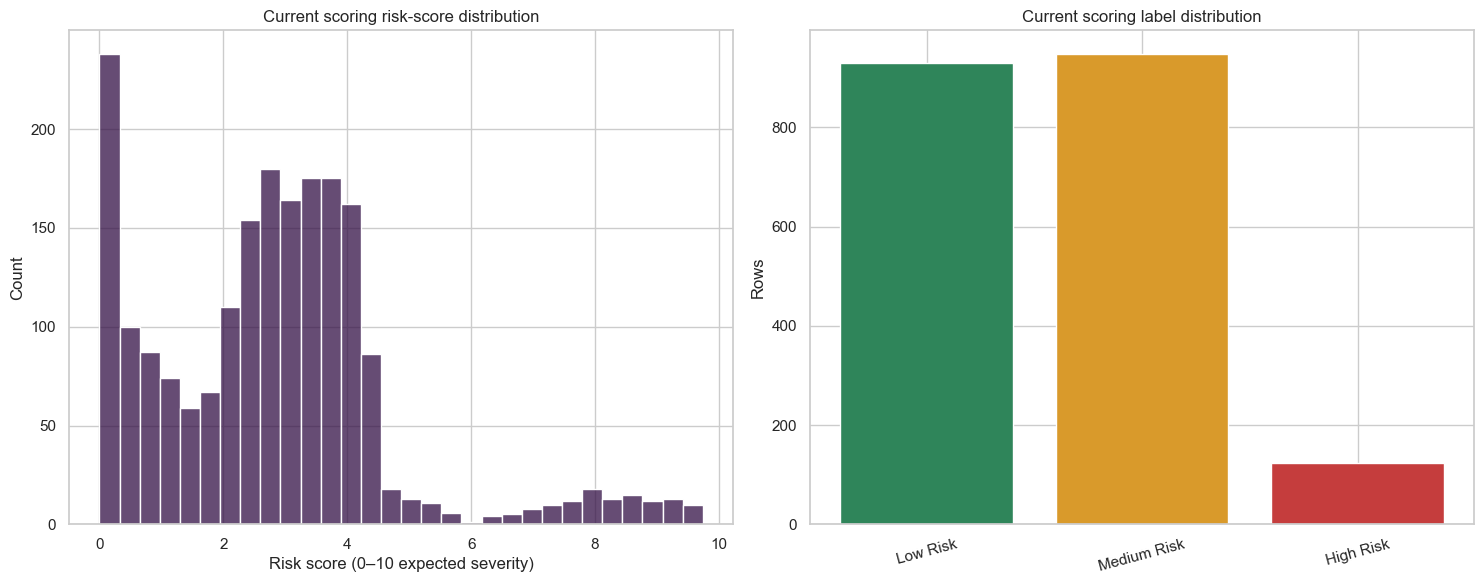

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

scoring_plot = current_scoring_risk_output.copy()
sns.histplot(
    data=scoring_plot,
    x="risk_score_0_10",
    bins=30,
    color="#331045",
    ax=axes[0])
axes[0].set_title("Current scoring risk-score distribution")
axes[0].set_xlabel("Risk score (0–10 expected severity)")

label_counts = (
    scoring_plot["predicted_risk_label"]
    .value_counts()
    .reindex(["Low Risk", "Medium Risk", "High Risk"], fill_value=0))
axes[1].bar(
    label_counts.index,
    label_counts.values,
    color=["#2F855A", "#D99A2B", "#C53D3D"])
axes[1].set_title("Current scoring label distribution")
axes[1].set_xlabel("")
axes[1].set_ylabel("Rows")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()


## 14. Export dashboard and interpretation artifacts


In [34]:
# Preserve every original output filename.
dashboard.to_csv(OUTPUT_DIR / "risk_predictions_for_dashboard.csv", sep=";", decimal=",", index=False)
top_high_risk_products.to_csv(OUTPUT_DIR / "top_high_risk_products.csv", index=False)
latest_month_top_high_risk_products.to_csv(
    OUTPUT_DIR / "latest_month_top_high_risk_products.csv", index=False)
model_interpretation_summary.to_csv(
    OUTPUT_DIR / "model_interpretation_summary.csv", index=False)
false_alarm_recall_tradeoff.to_csv(
    OUTPUT_DIR / "false_alarm_recall_tradeoff.csv", index=False)
risk_output_model_metrics.to_csv(
    OUTPUT_DIR / "risk_output_model_metrics.csv", index=False)
risk_output_feature_importance.to_csv(
    OUTPUT_DIR / "risk_output_feature_importance.csv", index=False)

for split, output in historical_evaluations.items():
    output[2].to_csv(OUTPUT_DIR / f"{split}_confusion_matrix.csv")
    output[1].to_csv(OUTPUT_DIR / f"{split}_classification_report.csv", index=False)

# Additional operational and interpretation outputs.
current_scoring_risk_output.to_csv(
    OUTPUT_DIR / "current_scoring_risk_output.csv", index=False)
current_alert_queue.to_csv(
    OUTPUT_DIR / "current_risk_alert_queue.csv", index=False)
scoring_local_path_contributions.to_csv(
    OUTPUT_DIR / "scoring_local_path_contributions.csv", index=False)
risk_output_feature_family_importance.to_csv(
    OUTPUT_DIR / "risk_output_feature_family_importance.csv", index=False)
risk_monitoring_by_month.to_csv(
    OUTPUT_DIR / "risk_monitoring_by_month.csv", index=False)
test_high_risk_probability_lift.to_csv(
    OUTPUT_DIR / "test_high_risk_probability_lift.csv", index=False)
inputs["confidence_intervals"].to_csv(
    OUTPUT_DIR / "risk_output_high_risk_confidence_intervals.csv", index=False)


In [30]:
risk_output_column_dictionary = pd.DataFrame(
    [
        {"column": "risk_score", "definition": "Legacy score: high-risk probability multiplied by 100.", "range": "0–100"},
        {"column": "risk_score_0_10", "definition": "Expected severity using 0×P(low) + 5×P(medium) + 10×P(high).", "range": "0–10"},
        {"column": "high_risk_probability", "definition": "Random Forest probability for class 2 (High Risk).", "range": "0–1"},
        {"column": "predicted_risk_label", "definition": "Risk label after applying the validated high-risk threshold.", "range": "Low / Medium / High"},
        {"column": "is_high_risk_alert", "definition": "1 when the thresholded prediction is High Risk.", "range": "0 / 1"},
        {"column": "is_false_alarm", "definition": "1 when a labeled non-high row was predicted High Risk; missing for scoring.", "range": "0 / 1 / missing"},
        {"column": "is_missed_high_risk", "definition": "1 when a labeled High Risk row was not predicted High Risk; missing for scoring.", "range": "0 / 1 / missing"},
        {"column": "model_driver_1", "definition": "Feature with the largest absolute local tree-path contribution for a scoring row.", "range": "Text"},
        {"column": "model_explained_class", "definition": "Predicted class whose probability is decomposed by the local model-driver fields.", "range": "Low / Medium / High"},
        {"column": "business_risk_indicators", "definition": "Up to five deterministic business conditions observed in human-readable features.", "range": "Text"},
        {"column": "recommended_action", "definition": "Rule-based operational suggestion derived from risk label and business indicators.", "range": "Text"},
        {"column": "monitoring_priority", "definition": "Sort order: High Risk=1, Medium Risk=2, Low Risk=3.", "range": "1–3"}])
risk_output_column_dictionary.to_csv(
    OUTPUT_DIR / "risk_output_column_dictionary.csv", index=False)
display(risk_output_column_dictionary)


,column,definition,range
0,risk_score,Legacy score: high-risk probability multiplied...,0–100
1,risk_score_0_10,Expected severity using 0×P(low) + 5×P(medium)...,0–10
2,high_risk_probability,Random Forest probability for class 2 (High Ri...,0–1
3,predicted_risk_label,Risk label after applying the validated high-r...,Low / Medium / High
4,is_high_risk_alert,1 when the thresholded prediction is High Risk.,0 / 1
5,is_false_alarm,1 when a labeled non-high row was predicted Hi...,0 / 1 / missing
6,is_missed_high_risk,1 when a labeled High Risk row was not predict...,0 / 1 / missing
7,model_driver_1,Feature with the largest absolute local tree-p...,Text
8,model_explained_class,Predicted class whose probability is decompose...,Low / Medium / High
9,business_risk_indicators,Up to five deterministic business conditions o...,Text


## 15. Final quality checks


In [31]:
original_required_outputs = [
    "risk_predictions_for_dashboard.csv",
    "top_high_risk_products.csv",
    "latest_month_top_high_risk_products.csv",
    "model_interpretation_summary.csv",
    "false_alarm_recall_tradeoff.csv",
    "false_alarm_recall_tradeoff.png",
    "risk_output_model_metrics.csv",
    "risk_output_feature_importance.csv",
    "train_confusion_matrix.csv",
    "valid_confusion_matrix.csv",
    "test_confusion_matrix.csv"]
required_legacy_prediction_columns = {
    "split",
    "actual_risk_label_num",
    "actual_risk_label",
    "predicted_risk_label_num",
    "predicted_risk_label",
    "prob_low_risk",
    "prob_medium_risk",
    "high_risk_probability",
    "risk_score",
    "is_high_risk_alert",
    "is_false_alarm",
    "is_missed_high_risk",
    "risk_drivers"}
required_legacy_metric_columns = {
    "split",
    "accuracy",
    "macro_f1",
    "weighted_f1",
    "high_risk_recall",
    "high_risk_precision",
    "false_alarm_rate",
    "alert_rate",
    "tp",
    "fp",
    "fn",
    "tn"}

final_checks = {
    "model_feature_contract_matches": all(feature_contract.values()),
    "feature_matrices_are_complete": feature_quality[["missing_values", "infinite_values", "duplicate_columns"]].eq(0).all().all(),
    "identifier_contract_matches": identifier_alignment[["rows_match", "target_values_match"]].all().all(),
    "identifier_keys_are_unique": identifier_alignment["duplicate_keys"].eq(0).all(),
    "upstream_predictions_reproduced": all(upstream_prediction_checks.values()),
    "selected_threshold_matches_model_config": np.isclose(selected_threshold, model_configuration["selected_high_risk_threshold"]),
    "dashboard_contains_all_pipeline_rows": len(dashboard) == len(inputs["human_features"]),
    "dashboard_key_is_unique": not dashboard.duplicated(KEY_COLS).any(),
    "human_context_join_coverage_is_complete": np.isclose(context_coverage, 1.0),
    "probabilities_sum_to_one": np.allclose(predictions[["prob_low_risk", "prob_medium_risk", "high_risk_probability"]].sum(axis=1), 1.0),
    "risk_score_is_in_legacy_range": dashboard["risk_score"].between(0, 100).all(),
    "risk_score_0_10_is_in_range": dashboard["risk_score_0_10"].between(0, 10).all(),
    "scoring_actual_labels_are_missing": current_scoring_risk_output["actual_risk_label_num"].isna().all(),
    "scoring_false_alarm_flags_are_missing": current_scoring_risk_output["is_false_alarm"].isna().all(),
    "local_explanations_reconstruct_probability": explanation_reconstruction_error.max() < 1e-10,
    "all_scoring_rows_have_local_drivers": current_scoring_risk_output["model_driver_1"].notna().all(),
    "global_importance_sums_to_one": np.isclose(risk_output_feature_importance["importance"].sum(), 1.0),
    "legacy_prediction_columns_preserved": required_legacy_prediction_columns.issubset(dashboard.columns),
    "legacy_metric_columns_preserved": required_legacy_metric_columns.issubset(risk_output_model_metrics.columns),
    "original_output_files_preserved": all((OUTPUT_DIR / name).exists() for name in original_required_outputs)}

quality_check_table = pd.DataFrame(
    {"check": list(final_checks.keys()), "passed": list(final_checks.values())})
display(quality_check_table)

failed_checks = quality_check_table.loc[~quality_check_table["passed"], "check"].tolist()
if failed_checks:
    raise AssertionError("Failed final checks: " + ", ".join(failed_checks))
print("All final interpretation and risk-output checks passed.")


,check,passed
0,model_feature_contract_matches,True
1,feature_matrices_are_complete,True
2,identifier_contract_matches,True
3,identifier_keys_are_unique,True
4,upstream_predictions_reproduced,True
5,selected_threshold_matches_model_config,True
6,dashboard_contains_all_pipeline_rows,True
7,dashboard_key_is_unique,True
8,human_context_join_coverage_is_complete,True
9,probabilities_sum_to_one,True


All final interpretation and risk-output checks passed.


In [32]:
model_interpretation_report = {
    "model": model_configuration["model_library"],
    "selected_candidate": model_configuration["selected_candidate"],
    "selected_high_risk_threshold": selected_threshold,
    "dashboard_rows": int(len(dashboard)),
    "current_scoring_rows": int(len(current_scoring_risk_output)),
    "current_alert_rows": int(len(current_alert_queue)),
    "latest_month": str(latest_month.date()),
    "chart_path": str(tradeoff_chart_path),
    "test_metrics": risk_output_model_metrics.loc[
        risk_output_model_metrics["split"] == "test"
    ].to_dict(orient="records"),
    "high_risk_confidence_intervals": inputs["confidence_intervals"].to_dict(orient="records"),
    "top_15_features": risk_output_feature_importance.head(15).to_dict(orient="records"),
    "feature_family_importance": risk_output_feature_family_importance.to_dict(orient="records"),
    "local_explanation_method": "Additive Random Forest tree-path probability contributions for each row's predicted class; not SHAP.",
    "maximum_local_explanation_reconstruction_error": float(explanation_reconstruction_error.max()),
    "quality_checks": final_checks}
with open(OUTPUT_DIR / "model_interpretation_report.json", "w", encoding="utf-8") as file:
    json.dump(model_interpretation_report, file, indent=2, default=str)

with open(OUTPUT_DIR / "risk_output_quality_report.json", "w", encoding="utf-8") as file:
    json.dump(
        {
            "artifact_inventory": artifact_inventory.to_dict(orient="records"),
            "feature_contract": feature_contract,
            "feature_quality": feature_quality.to_dict(orient="records"),
            "identifier_alignment": identifier_alignment.to_dict(orient="records"),
            "upstream_prediction_checks": upstream_prediction_checks,
            "context_coverage": context_coverage,
            "local_explanation_check": explanation_check.to_dict(orient="records"),
            "final_checks": final_checks},
        file,
        indent=2,
        default=str)

In [33]:
export_summary = pd.DataFrame(
    [
        {"file": path.name, "size_bytes": path.stat().st_size}
        for path in sorted(OUTPUT_DIR.iterdir())
        if path.is_file()])
display(export_summary)

print("\nInterpretation and risk output complete")
print("-" * 80)
print(f"Dashboard rows:           {len(dashboard):,}")
print(f"Current scoring rows:     {len(current_scoring_risk_output):,}")
print(f"Current alert queue rows: {len(current_alert_queue):,}")
print(f"High-risk threshold:      {selected_threshold:.4f}")
print(f"Latest scoring month:     {latest_month:%Y-%m}")
print(f"Context coverage:         {context_coverage:.2%}")
print(f"Output folder:            {OUTPUT_DIR.resolve()}")


,file,size_bytes
0,current_risk_alert_queue.csv,1158258
1,current_scoring_risk_output.csv,2154709
2,false_alarm_recall_tradeoff.csv,53648
3,false_alarm_recall_tradeoff.png,175807
4,latest_month_top_high_risk_products.csv,104772
5,model_interpretation_report.json,8250
6,model_interpretation_summary.csv,1172
7,risk_monitoring_by_month.csv,5383
8,risk_output_column_dictionary.csv,1201
9,risk_output_feature_family_importance.csv,713



Interpretation and risk output complete
--------------------------------------------------------------------------------
Dashboard rows:           120,000
Current scoring rows:     2,000
Current alert queue rows: 1,071
High-risk threshold:      0.4300
Latest scoring month:     2025-12
Context coverage:         100.00%
Output folder:            C:\Benutzer\Anastasia\Lokale Daten\AS Portfolio\early-warning\data\full_data\ml_interpretation_risk_output
